In [2]:
import pandas as pd
import pyarrow.parquet as pq

file_path = "/content/liquor_2022_2026.parquet"

# See the file's size, row count, and column names without loading it all into pandas
parquet_file = pq.ParquetFile(file_path)

print("Rows:", f"{parquet_file.metadata.num_rows:,}")
print("Columns:", parquet_file.metadata.num_columns)
print("\nColumn names:")
print(parquet_file.schema.names)

Rows: 13,247,692
Columns: 23

Column names:
['invoice_id', 'ordered_on', 'store_no', 'store_name', 'store_address', 'store_city', 'store_zip_code', 'county_fips_code', 'county_name', 'category_code', 'category_name', 'vendor_number', 'vendor_name', 'item_no', 'im_desc', 'pack', 'bottle_volume_ml', 'state_bottle_cost', 'state_bottle_retail', 'sales_bottles', 'sales_dollars', 'sales_liters', 'sales_gallons']


In [3]:
preview_columns = [
    "invoice_id",
    "ordered_on",
    "store_name",
    "store_city",
    "county_name",
    "category_name",
    "pack",
    "bottle_volume_ml",
    "sales_bottles",
    "sales_liters",
    "sales_dollars"
]

preview_df = pd.read_parquet(
    file_path,
    columns=preview_columns
).head(15)

preview_df

,invoice_id,ordered_on,store_name,store_city,county_name,category_name,pack,bottle_volume_ml,sales_bottles,sales_liters,sales_dollars
0,INV-52123300019,2022-10-14,ROUND WINDOW LIQUOR / KNOXVILLE,KNOXVILLE,MARION,TRIPLE SEC,12,1000,3,3.00,10.89
1,INV-52123300025,2022-10-14,ROUND WINDOW LIQUOR / KNOXVILLE,KNOXVILLE,MARION,WHISKEY LIQUEUR,12,50,1,0.05,7.50
2,INV-52123300009,2022-10-14,ROUND WINDOW LIQUOR / KNOXVILLE,KNOXVILLE,MARION,WHISKEY LIQUEUR,24,375,48,18.00,384.00
3,INV-52123600076,2022-10-14,NEW STAR / KNOXVILLE,KNOXVILLE,MARION,WHISKEY LIQUEUR,12,750,12,9.00,162.00
4,INV-52123100008,2022-10-14,CASEY'S GENERAL STORE #3217 / KNOXVILLE,KNOXVILLE,MARION,WHISKEY LIQUEUR,24,375,24,9.00,192.00
5,INV-52123300010,2022-10-14,ROUND WINDOW LIQUOR / KNOXVILLE,KNOXVILLE,MARION,WHISKEY LIQUEUR,48,100,96,9.60,129.60
6,INV-52122800028,2022-10-14,WAL-MART 2935 / KNOXVILLE,KNOXVILLE,MARION,WHISKEY LIQUEUR,6,1750,6,10.50,138.00
7,INV-52123100005,2022-10-14,CASEY'S GENERAL STORE #3217 / KNOXVILLE,KNOXVILLE,MARION,WHISKEY LIQUEUR,8,100,8,0.80,72.00
8,INV-52122800046,2022-10-14,WAL-MART 2935 / KNOXVILLE,KNOXVILLE,MARION,WHISKEY LIQUEUR,8,100,24,2.40,216.00
9,INV-52123700039,2022-10-14,HY-VEE FOOD STORE / KNOXVILLE,KNOXVILLE,MARION,WHISKEY LIQUEUR,12,50,96,4.80,619.20


In [4]:
city_columns = [
    "store_city",
    "category_name",
    "sales_liters",
    "sales_bottles",
    "sales_dollars"
]

city_df = pd.read_parquet(
    file_path,
    columns=city_columns
)

# Make sure sales fields are numeric
for col in ["sales_liters", "sales_bottles", "sales_dollars"]:
    city_df[col] = pd.to_numeric(city_df[col], errors="coerce")

# Exclude returns/adjustments and missing city/category records
city_df = city_df[
    (city_df["sales_liters"] >= 0) &
    city_df["store_city"].notna() &
    city_df["category_name"].notna()
].copy()

# Sorting top cities by total liters
top_cities = (
    city_df.groupby("store_city", as_index=False)
    .agg(
        total_liters=("sales_liters", "sum"),
        total_sales_dollars=("sales_dollars", "sum")
    )
    .sort_values("total_liters", ascending=False)
    .head(15)
)

top_cities

,store_city,total_liters,total_sales_dollars
117,DES MOINES,1.283649e+07,2.675590e+08
70,CEDAR RAPIDS,7.434060e+06,1.428989e+08
107,DAVENPORT,5.534950e+06,1.039516e+08
467,WEST DES MOINES,4.661118e+06,9.901161e+07
99,COUNCIL BLUFFS,3.893361e+06,7.798673e+07
401,SIOUX CITY,3.752768e+06,7.252173e+07
218,IOWA CITY,3.507169e+06,6.592494e+07
23,ANKENY,3.423316e+06,6.718523e+07
453,WATERLOO,3.322175e+06,6.437392e+07
124,DUBUQUE,3.132517e+06,5.524646e+07


Des Moines had the highest total liquor volume ordered by retailers, with approximately 12.8 million liters across the available 2022–2026 data.

In [5]:
# Select the ten cities with the highest total liquor volume
major_cities = top_cities["store_city"].head(10).tolist()

# Total liters sold for each city-category combination
city_category_sales = (
    city_df[city_df["store_city"].isin(major_cities)]
    .groupby(["store_city", "category_name"], as_index=False)
    .agg(total_liters=("sales_liters", "sum"))
)

# Calculate each category's share of its city's total volume
city_totals = (
    city_category_sales.groupby("store_city", as_index=False)
    .agg(city_total_liters=("total_liters", "sum"))
)

city_category_sales = city_category_sales.merge(
    city_totals,
    on="store_city",
    how="left"
)

city_category_sales["percent_of_city_volume"] = (
    100 * city_category_sales["total_liters"]
    / city_category_sales["city_total_liters"]
)

# Rank categories within each city and retain each city's top five
city_category_sales["category_rank"] = (
    city_category_sales.groupby("store_city")["total_liters"]
    .rank(method="first", ascending=False)
)

city_top_categories = (
    city_category_sales[city_category_sales["category_rank"] <= 5]
    .sort_values(["store_city", "category_rank"])
)

city_top_categories[
    [
        "store_city",
        "category_rank",
        "category_name",
        "total_liters",
        "percent_of_city_volume"
    ]
]

,store_city,category_rank,category_name,total_liters,percent_of_city_volume
12,ANKENY,1.0,AMERICAN VODKAS,781903.460,22.840531
15,ANKENY,2.0,CANADIAN WHISKIES,344772.550,10.071305
42,ANKENY,3.0,STRAIGHT BOURBON WHISKIES,287510.790,8.398606
16,ANKENY,4.0,COCKTAILS/RTD,240047.565,7.012136
41,ANKENY,5.0,SPICED RUM,184120.120,5.378415
60,CEDAR RAPIDS,1.0,AMERICAN VODKAS,1997190.815,26.865413
63,CEDAR RAPIDS,2.0,CANADIAN WHISKIES,706587.140,9.504728
91,CEDAR RAPIDS,3.0,STRAIGHT BOURBON WHISKIES,480154.735,6.458850
90,CEDAR RAPIDS,4.0,SPICED RUM,451255.955,6.070115
96,CEDAR RAPIDS,5.0,WHISKEY LIQUEUR,334311.360,4.497023


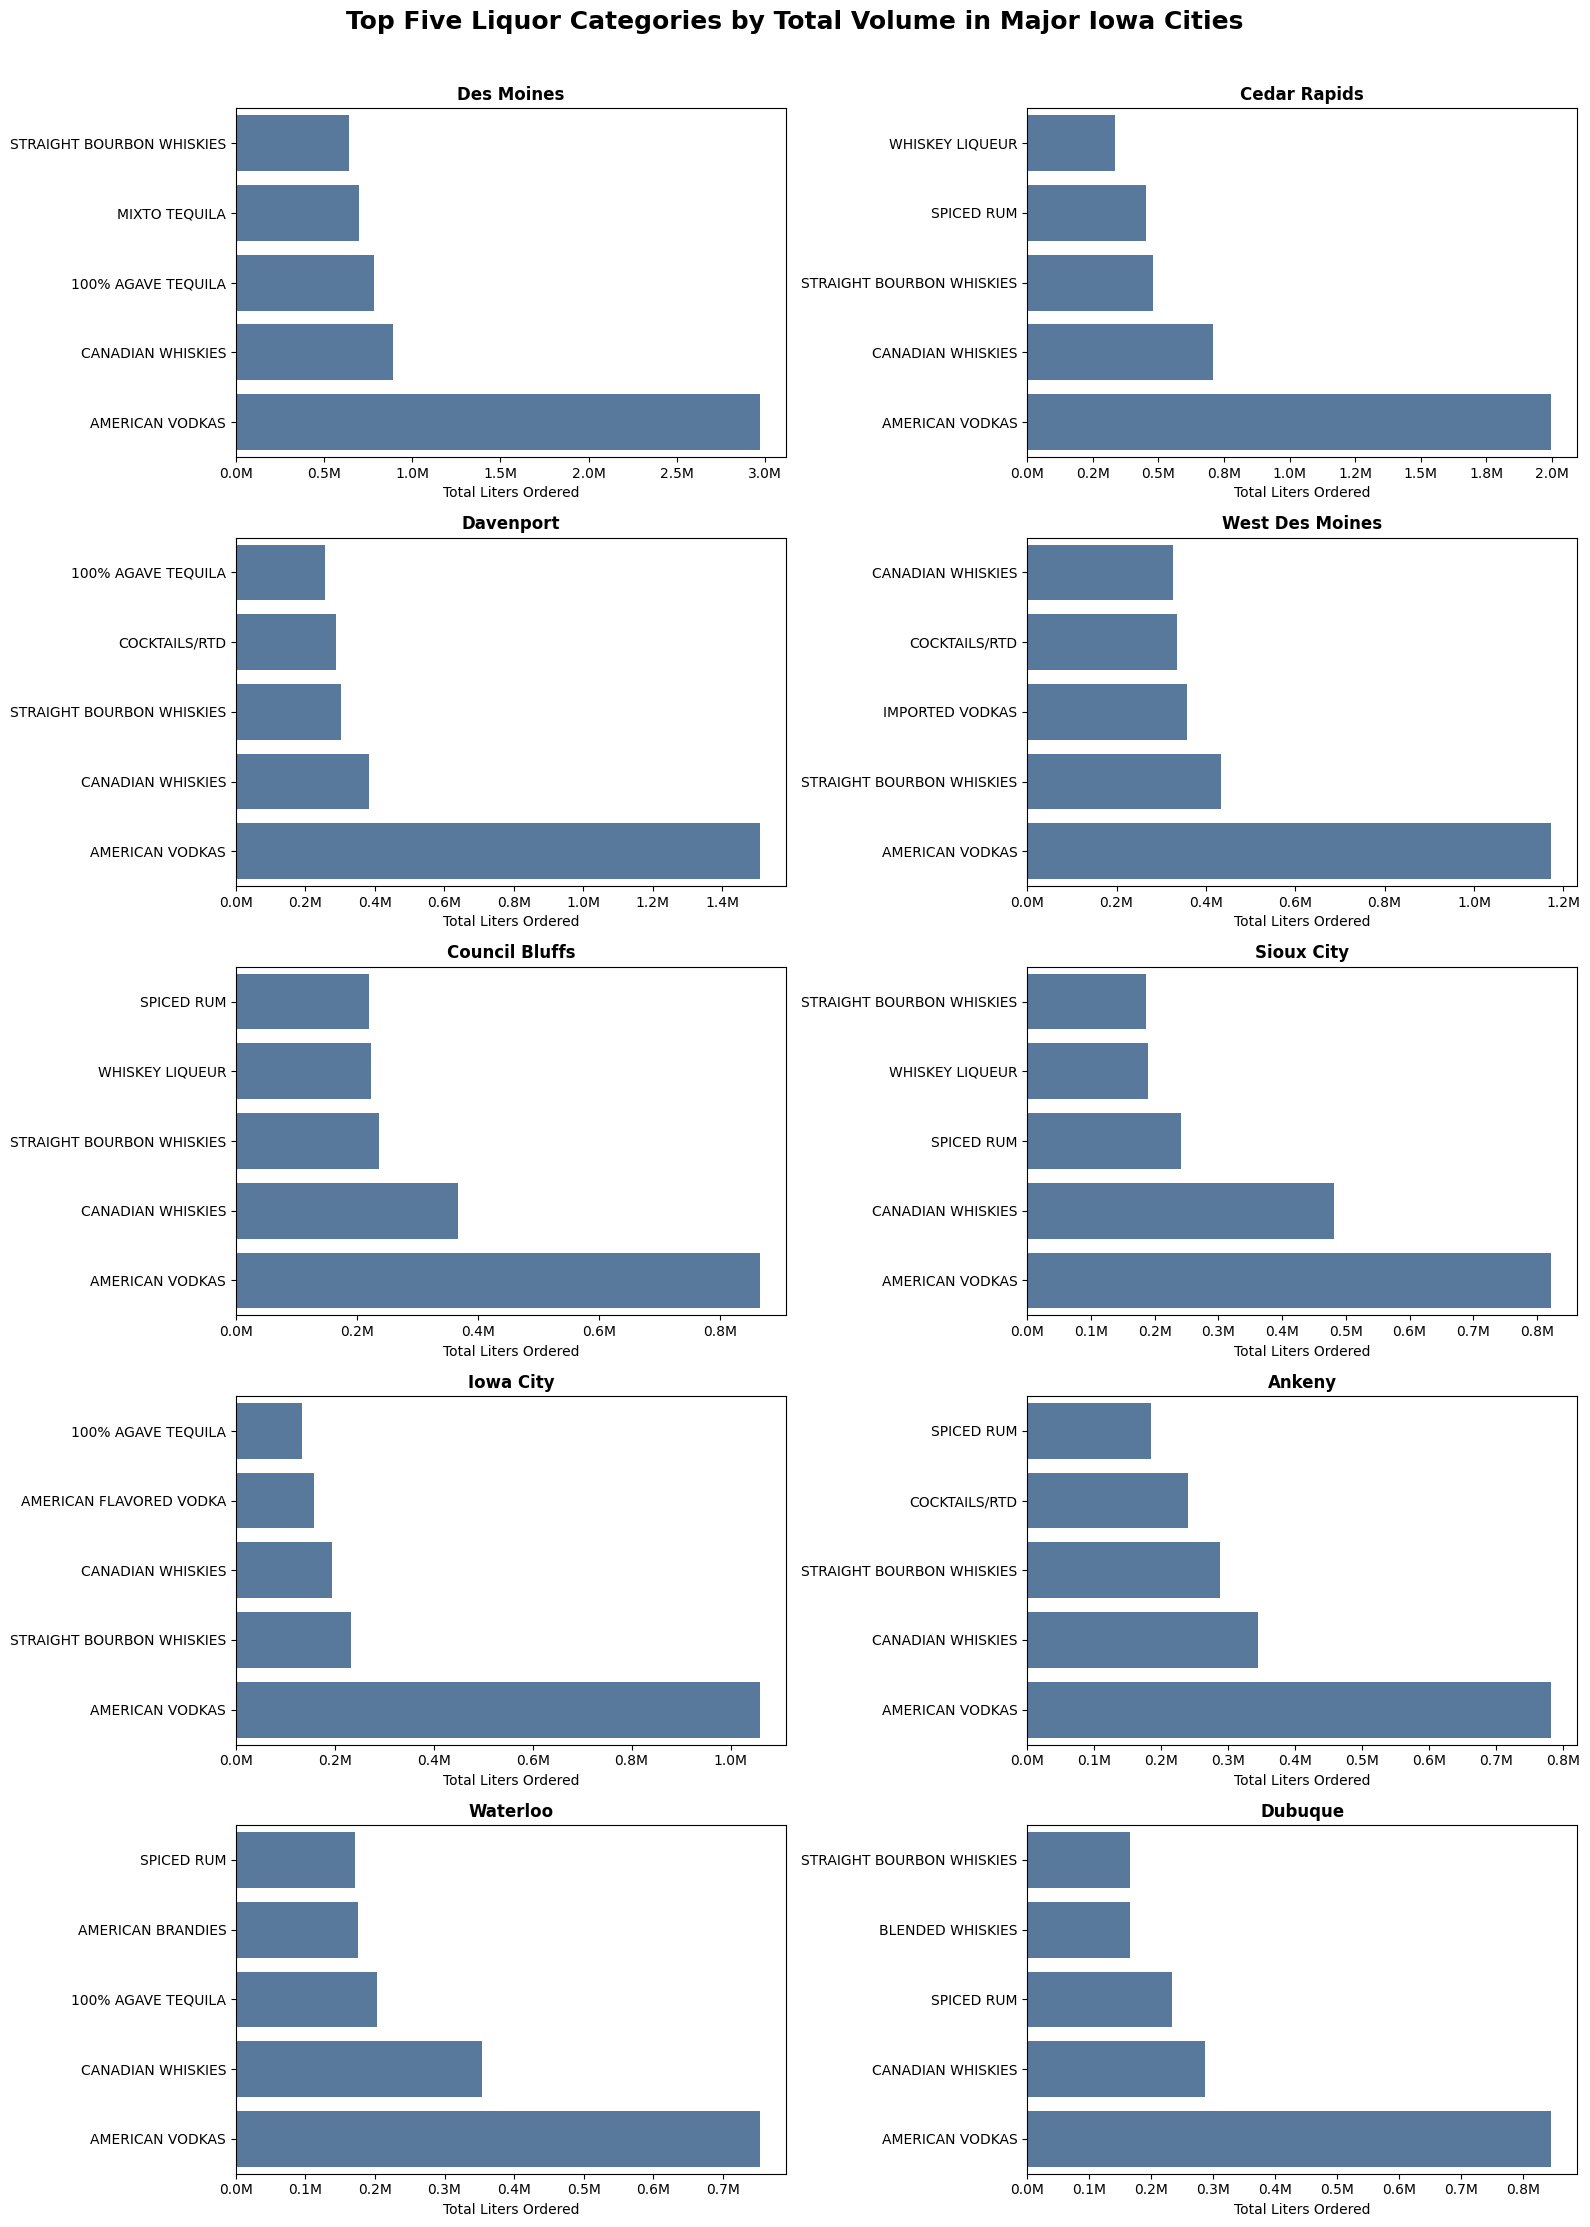

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# city_top_categories already contains the top five categories by total liters
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for ax, city in zip(axes, major_cities):
    city_data = (
        city_top_categories[city_top_categories["store_city"] == city]
        .sort_values("total_liters", ascending=True)
    )

    sns.barplot(
        data=city_data,
        x="total_liters",
        y="category_name",
        ax=ax,
        color="#4C78A8"
    )

    ax.set_title(city.title(), fontweight="bold")
    ax.set_xlabel("Total Liters Ordered")
    ax.set_ylabel("")

    # Display large numbers as millions, such as 0.8M
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x / 1_000_000:.1f}M")
    )

# Remove any unused chart areas
for ax in axes[len(major_cities):]:
    ax.remove()

fig.suptitle(
    "Top Five Liquor Categories by Total Volume in Major Iowa Cities",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

## Variable Descriptions
* store_city: The Iowa city where the retailer placing the liquor order is loacted

* category_rank: The category’s rank within that city based on total liters ordered. A rank of 1 means it is the highest-volume liquor category in that city.

* category_name: The type of liquor product, such as American Vodkas, Canadian Whiskies, or Straight Bourbon Whiskies.

* total_liters: The total number of liters of that liquor category ordered by retailers in the city across the available 2022–2026 data.

* percent_of_city_volume: The percentage of the city’s total liquor volume represented by that category. For example, 22.84 means the category makes up about 22.84% of all liters ordered in that city.

## Summary of Findings

Across the ten largest Iowa city markets, American Vodkas were the highest volume liquor category in every city. Canadian Whiskies were also consistently among the most popular categories, often ranking second. However, the results show that some cities have different category preferences beyond these statewide favorites. For example, tequila categories were especially prominent in Des Moines, while Iowa City showed relatively strong demand for bourbon, flavored vodka, and gin. These findings suggest that Booze ’R’ Us could use location-specific promotions rather than promoting the exact same liquor categories in every city.

In [10]:
# Statewide share of each category
statewide_categories = (
    city_df.groupby("category_name", as_index=False)
    .agg(statewide_liters=("sales_liters", "sum"))
)

statewide_total_liters = statewide_categories["statewide_liters"].sum()

statewide_categories["statewide_percent"] = (
    100 * statewide_categories["statewide_liters"] / statewide_total_liters
)

# Merge statewide category shares into the city-category table
city_preferences = city_category_sales.merge(
    statewide_categories[["category_name", "statewide_percent"]],
    on="category_name",
    how="left"
)

# An index above 1 means the category is more popular in that city than statewide
city_preferences["preference_index"] = (
    city_preferences["percent_of_city_volume"]
    / city_preferences["statewide_percent"]
)

# Keep meaningful categories: at least 2% of that city's liquor volume
meaningful_preferences = city_preferences[
    city_preferences["percent_of_city_volume"] >= 2
].copy()

# Show the five categories that over-index most in each major city
meaningful_preferences["preference_rank"] = (
    meaningful_preferences.groupby("store_city")["preference_index"]
    .rank(method="first", ascending=False)
)

city_specific_categories = (
    meaningful_preferences[meaningful_preferences["preference_rank"] <= 5]
    .sort_values(["store_city", "preference_rank"])
)

city_specific_categories[
    [
        "store_city",
        "preference_rank",
        "category_name",
        "percent_of_city_volume",
        "statewide_percent",
        "preference_index"
    ]
]

,store_city,preference_rank,category_name,percent_of_city_volume,statewide_percent,preference_index
40,ANKENY,1.0,SPECIAL ORDER ITEMS,2.538582,0.564807,4.494604
19,ANKENY,2.0,CREAM LIQUEURS,2.817277,1.437937,1.959249
16,ANKENY,3.0,COCKTAILS/RTD,7.012136,3.925193,1.786444
42,ANKENY,4.0,STRAIGHT BOURBON WHISKIES,8.398606,5.901145,1.423216
1,ANKENY,5.0,100% AGAVE TEQUILA,4.302500,3.315228,1.297799
49,CEDAR RAPIDS,1.0,100% AGAVE TEQUILA,3.957582,3.315228,1.193759
91,CEDAR RAPIDS,2.0,STRAIGHT BOURBON WHISKIES,6.458850,5.901145,1.094508
60,CEDAR RAPIDS,3.0,AMERICAN VODKAS,26.865413,24.609577,1.091665
90,CEDAR RAPIDS,4.0,SPICED RUM,6.070115,5.926884,1.024166
96,CEDAR RAPIDS,5.0,WHISKEY LIQUEUR,4.497023,4.573900,0.983192


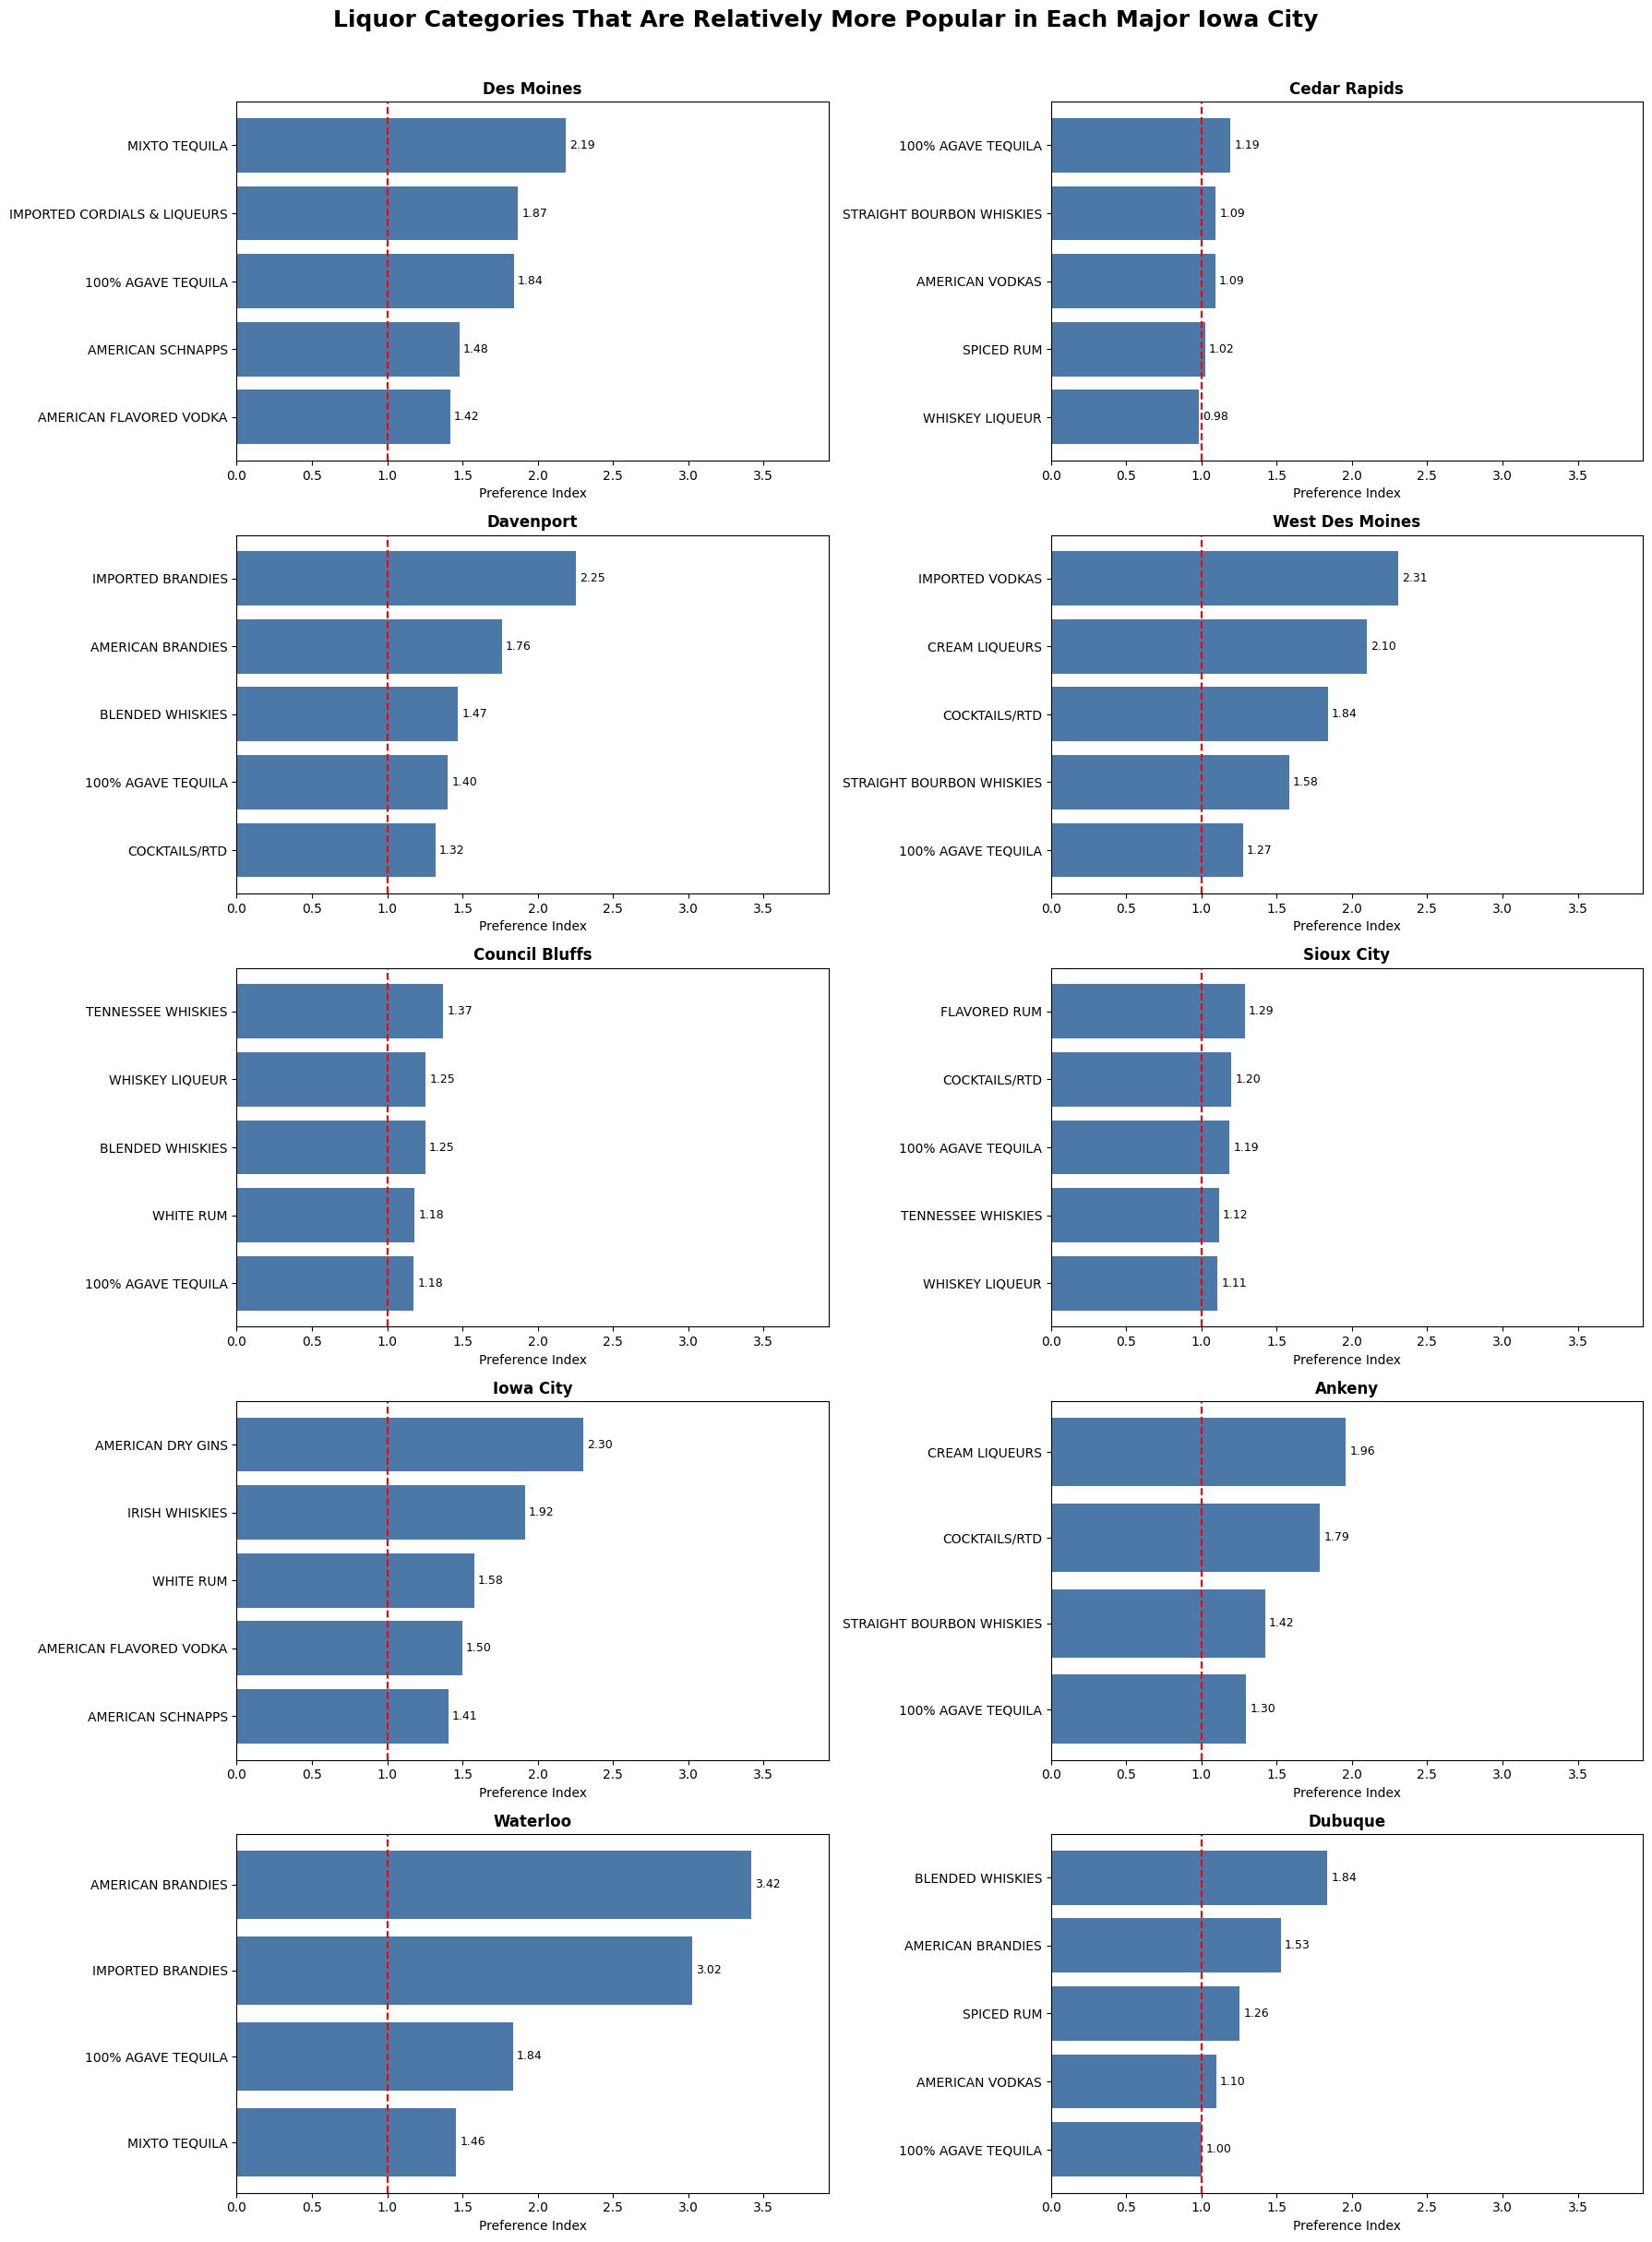

In [11]:
# Remove broad/non-actionable category
plot_df = city_specific_categories[
    city_specific_categories["category_name"] != "SPECIAL ORDER ITEMS"
].copy()

# Use a common x-axis so bar lengths are comparable across cities
max_index = plot_df["preference_index"].max() * 1.15

fig, axes = plt.subplots(5, 2, figsize=(18, 24))
axes = axes.flatten()

for ax, city in zip(axes, major_cities):
    city_data = (
        plot_df[plot_df["store_city"] == city]
        .sort_values("preference_index", ascending=True)
    )

    bars = ax.barh(
        city_data["category_name"],
        city_data["preference_index"],
        color="#4C78A8"
    )

    # 1 = same category share as Iowa overall
    ax.axvline(1, color="red", linestyle="--", linewidth=1.5)

    ax.bar_label(
        bars,
        labels=[f"{value:.2f}" for value in city_data["preference_index"]],
        padding=3,
        fontsize=9
    )

    ax.set_title(city.title(), fontweight="bold")
    ax.set_xlabel("Preference Index")
    ax.set_ylabel("")
    ax.set_xlim(0, max_index)

# Remove unused chart areas if necessary
for ax in axes[len(major_cities):]:
    ax.remove()

fig.suptitle(
    "Liquor Categories That Are Relatively More Popular in Each Major Iowa City",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

## Variable Description

* store_city - percent_of_city_volume is the same as above.

* statewide_percent: The percentage of all liquor liters ordered across Iowa that came from the category.

* preference_index: Compares the category's share in a city with its share statewide. A value of 1 means the category has the same share in the city as in Iowa overall. A value greater than 1 means the category is relatively more popular in that city and a value below 1 means it is relatively less popular.

## Summary of Findings

The chart shows that the liquor category mix differs across cities in Iowa when compared with the statewide average. Waterloo has the strongest local differences, with American Brandies and Imported Brandies representing more than three times their statewide shares. Iowa City shows relatively high demand for American Dry Gins and Irish Whiskies, while West Des Moines stands out for Imported Vodkas, Cream Liqueurs, and Cocktails/RTD. Des Moines has relatively strong demand for tequila categories, especially Mixto Tequila. In comparison, Cedar Rapids and Sioux City have category mixes that are closer to the statewide average. These results support using city specific inventory and promotion strategies instead of applying the same approach throughout Iowa.